# Graph Coloring CSD Sampling Experiment

**Critical Slowing Down (CSD) Indicators for LLM Capability Boundary Detection**

This notebook demonstrates the analysis pipeline from the CSD sampling experiment on graph coloring constraint satisfaction problems. Three LLMs (GPT-4o-mini, Gemini-2.0-Flash, Gemini-2.0-Flash-Lite) were evaluated across 20 difficulty levels.

**What this artifact does:**
1. Loads pre-generated LLM responses to graph coloring problems
2. Parses and evaluates constraint satisfaction (correct coloring)
3. Computes CSD indicator battery (variance, dip test, silhouette, bimodality coefficient, Ashman D, disagreement)
4. Analyzes d* (capability boundary), scaling exponents, and leading indicators
5. Compares CSD-based classifier vs disagreement-only baseline

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('diptest')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import random
import re
import time
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## Load Experiment Data

Load pre-generated LLM responses from the CSD sampling experiment. The data contains responses from 3 models across 20 difficulty levels on graph coloring problems.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/experiment_iter2_graph_coloring/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} model datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded data with 3 model datasets
  graph_coloring_csd_gpt-4o-mini: 20 examples
  graph_coloring_csd_gemini-2.0-flash-001: 20 examples
  graph_coloring_csd_gemini-2.0-flash-lite-001: 20 examples


## Configuration

Tunable parameters for the analysis. These control which models/levels to process and thresholds for CSD indicators.

In [5]:
# --- Config: analysis parameters ---
# Number of models to analyze (max 3)
N_MODELS = 3  # original: 3
# Number of difficulty levels to analyze (max 20)
N_LEVELS = 20  # original: 20
# Embedding batch size for sentence-transformers
EMBED_BATCH_SIZE = 32  # original: 64
# Seed for reproducibility
SEED = 42
# Accuracy threshold for d* estimation
D_STAR_ACCURACY_THRESHOLD = 0.5
# Dip test significance level
DIP_ALPHA = 0.05
# Silhouette threshold for leading indicator
SILHOUETTE_THRESHOLD = 0.3
# LogReg max iterations
LOGREG_MAX_ITER = 1000

# Color sets for graph coloring validation
COLOR_SETS = {
    3: {"red", "green", "blue"},
    4: {"red", "green", "blue", "yellow"},
}

## Step 1: Parse and Evaluate Constraint Satisfaction

Parse LLM coloring responses using multiple strategies (Node X: Color patterns, JSON-like, final-answer sections) and verify constraint satisfaction against the graph adjacency.

In [6]:
def parse_coloring(response_text: str, num_nodes: int, num_colors: int) -> dict | None:
    """Robust parser: extract node->color assignments from LLM response."""
    if not response_text:
        return None

    allowed_colors = COLOR_SETS.get(num_colors, COLOR_SETS[3])
    color_pattern = "|".join(allowed_colors)
    coloring: dict[int, str] = {}

    # Strategy 1: "Node X: Color"
    pattern1 = rf"[Nn]ode\s*(\d+)\s*[:=\->]+\s*({color_pattern})"
    all_match_positions = list(re.finditer(pattern1, response_text, re.IGNORECASE))
    if all_match_positions:
        last_block: list[tuple[str, str]] = []
        for m_obj in reversed(all_match_positions):
            node_id = int(m_obj.group(1))
            color = m_obj.group(2).lower()
            if node_id < num_nodes:
                last_block.append((str(node_id), color))
            if len(last_block) >= num_nodes:
                break
        for node_str, color in last_block:
            coloring[int(node_str)] = color

    # Strategy 2: "X: Color" without Node prefix
    if len(coloring) < num_nodes:
        pattern2 = rf"(?<!\w)(\d+)\s*[:=\->]+\s*({color_pattern})(?!\w)"
        matches2 = re.findall(pattern2, response_text, re.IGNORECASE)
        for node_str, color in matches2:
            node_id = int(node_str)
            if node_id < num_nodes and node_id not in coloring:
                coloring[node_id] = color.lower()

    # Strategy 3: Look in final answer section
    if len(coloring) < num_nodes:
        for marker in ["final answer", "answer:", "solution:", "coloring:"]:
            idx = response_text.lower().rfind(marker)
            if idx >= 0:
                tail = response_text[idx:]
                tail_matches = re.findall(pattern1, tail, re.IGNORECASE)
                for node_str, color in tail_matches:
                    node_id = int(node_str)
                    if node_id < num_nodes:
                        coloring[node_id] = color.lower()

    # Strategy 4: JSON-like {"0": "red", ...}
    if len(coloring) < num_nodes:
        json_pattern = rf'"?(\d+)"?\s*:\s*"?({color_pattern})"?'
        json_matches = re.findall(json_pattern, response_text, re.IGNORECASE)
        for node_str, color in json_matches:
            node_id = int(node_str)
            if node_id < num_nodes and node_id not in coloring:
                coloring[node_id] = color.lower()

    # Validate
    if set(coloring.keys()) != set(range(num_nodes)):
        return None
    if not all(c in allowed_colors for c in coloring.values()):
        return None
    return coloring


def check_constraint_satisfaction(coloring: dict[int, str], adjacency: list[list[int]]) -> bool:
    """Verify no two adjacent nodes share a color."""
    for edge in adjacency:
        u, v = edge[0], edge[1]
        if coloring.get(u) == coloring.get(v):
            return False
    return True


# Flatten all examples across datasets, keeping model info
all_responses = []
datasets_to_use = data['datasets'][:N_MODELS]
for ds in datasets_to_use:
    for ex in ds['examples']:
        level = ex['metadata_difficulty_level']
        if level > N_LEVELS:
            continue
        all_responses.append(ex)

# Re-parse and verify correctness from the response text
n_parsed = 0
n_correct = 0
for resp in all_responses:
    response_text = resp.get('predict_model_response', '')
    num_nodes = resp.get('metadata_num_nodes', 4)
    num_colors = resp.get('metadata_num_colors', 3)

    coloring = parse_coloring(response_text, num_nodes, num_colors)
    resp['_parsed_coloring'] = coloring
    resp['_parsed'] = coloring is not None
    # Use pre-computed correctness from the data (since we have truncated responses)
    resp['_correct'] = resp.get('predict_is_correct', 'false') == 'true'

    if resp['_parsed']:
        n_parsed += 1
    if resp['_correct']:
        n_correct += 1

print(f"Total responses: {len(all_responses)}")
print(f"Parsed: {n_parsed}/{len(all_responses)} ({n_parsed/max(len(all_responses),1)*100:.1f}%)")
print(f"Correct: {n_correct}/{len(all_responses)} ({n_correct/max(len(all_responses),1)*100:.1f}%)")

Total responses: 60
Parsed: 59/60 (98.3%)
Correct: 35/60 (58.3%)


## Step 2: Embed Responses

Embed response texts into a vector space for CSD indicator computation. The original experiment used sentence-transformers (all-MiniLM-L6-v2). For this lightweight demo, we use TF-IDF embeddings from sklearn, which demonstrate the same CSD analysis pipeline without requiring a large neural model download.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

valid_texts = []
valid_indices = []
for i, r in enumerate(all_responses):
    text = r.get('predict_model_response', '')
    if text:
        valid_texts.append(text)
        valid_indices.append(i)

print(f"Embedding {len(valid_texts)} response texts with TF-IDF...")
t0 = time.time()
# Original experiment used: SentenceTransformer("all-MiniLM-L6-v2")
# Demo uses TF-IDF for speed (no torch download needed)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
embeddings = vectorizer.fit_transform(valid_texts).toarray()
embeddings = normalize(embeddings)  # L2 normalize like sentence-transformers
print(f"Embedding shape: {embeddings.shape}, took {time.time()-t0:.1f}s")

embed_idx_map = {orig_idx: emb_idx for emb_idx, orig_idx in enumerate(valid_indices)}

Embedding 60 response texts with TF-IDF...
Embedding shape: (60, 237), took 0.0s


## Step 3: Compute CSD Indicators

For each (model, difficulty level) group, compute the full CSD indicator battery:
- **Embedding variance**: mean pairwise cosine distance between responses
- **PC1 variance**: variance along first principal component
- **Hartigan's dip test**: test for multimodality in PC1 projections
- **Silhouette score**: cluster separation quality (k=2 k-means)
- **Bimodality coefficient**: skewness/kurtosis-based bimodality measure
- **Disagreement rate**: fraction of responses differing from the mode
- **Ashman's D**: separation between correct/incorrect response clusters

In [8]:
import diptest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sil_fn
from sklearn.decomposition import PCA
from scipy.stats import skew, kurtosis


def _empty_indicators() -> dict:
    return {
        "accuracy": 0.0, "n_responses": 0, "n_correct": 0, "n_parsed": 0,
        "embedding_variance": 0.0, "pc1_variance": 0.0,
        "dip_statistic": 0.0, "dip_pvalue": 1.0,
        "silhouette_score": 0.0, "bimodality_coefficient": 0.0,
        "disagreement_rate": 1.0, "ashman_d": 0.0,
    }


def compute_csd_indicators(
    group_embeddings: np.ndarray,
    correctness: list[bool],
    colorings: list[dict | None],
) -> dict:
    """Compute full CSD indicator battery for one (model, level) group."""
    N = len(correctness)
    if N == 0:
        return _empty_indicators()

    accuracy = sum(correctness) / N

    # 1. Embedding Variance
    if N > 1:
        sim_matrix = group_embeddings @ group_embeddings.T
        dist_matrix = 1.0 - sim_matrix
        mask = ~np.eye(N, dtype=bool)
        embedding_variance = float(np.mean(dist_matrix[mask]))
    else:
        embedding_variance = 0.0

    # PC1 projection
    if N >= 3:
        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(group_embeddings).flatten()
        pc1_variance = float(np.var(pc1))
    else:
        pc1 = np.zeros(N)
        pc1_variance = 0.0

    # 2. Hartigan's Dip Test
    if N >= 4:
        try:
            dip_stat, dip_pval = diptest.diptest(pc1)
            dip_stat, dip_pval = float(dip_stat), float(dip_pval)
        except Exception:
            dip_stat, dip_pval = 0.0, 1.0
    else:
        dip_stat, dip_pval = 0.0, 1.0

    # 3. Silhouette Score (k=2 k-means)
    if N >= 4:
        try:
            kmeans = KMeans(n_clusters=2, n_init=10, random_state=SEED)
            labels = kmeans.fit_predict(group_embeddings)
            if len(set(labels)) == 2:
                sil_score = float(sil_fn(group_embeddings, labels))
            else:
                sil_score = 0.0
        except Exception:
            sil_score = 0.0
    else:
        sil_score = 0.0

    # 4. Bimodality Coefficient
    if N >= 4:
        try:
            s = float(skew(pc1))
            k = float(kurtosis(pc1, fisher=True))
            n = N
            denom_factor = (n - 2) * (n - 3)
            denom = k + 3.0 * (n - 1) ** 2 / denom_factor if denom_factor != 0 else 1.0
            bc = (s**2 + 1) / denom if denom != 0 else 0.0
        except Exception:
            bc = 0.0
    else:
        bc = 0.0

    # 5. Disagreement Rate
    answer_strs = []
    for c in colorings:
        if c is not None:
            answer_strs.append(str(sorted(c.items())))
        else:
            answer_strs.append("PARSE_FAIL")
    answer_counts = Counter(answer_strs)
    most_common_count = answer_counts.most_common(1)[0][1] if answer_counts else 0
    disagreement = 1.0 - (most_common_count / N) if N > 0 else 1.0

    # 6. Ashman's D
    correct_idx = [i for i, c in enumerate(correctness) if c]
    incorrect_idx = [i for i, c in enumerate(correctness) if not c]
    if len(correct_idx) >= 2 and len(incorrect_idx) >= 2:
        pc1_correct = pc1[correct_idx]
        pc1_incorrect = pc1[incorrect_idx]
        mu1, mu2 = float(np.mean(pc1_correct)), float(np.mean(pc1_incorrect))
        s1, s2 = float(np.std(pc1_correct)), float(np.std(pc1_incorrect))
        ashman_d = float(np.sqrt(2) * abs(mu1 - mu2) / np.sqrt(s1**2 + s2**2)) if (s1**2 + s2**2) > 0 else 0.0
    else:
        ashman_d = 0.0

    return {
        "accuracy": round(accuracy, 4),
        "n_responses": N,
        "n_correct": int(sum(correctness)),
        "n_parsed": int(sum(1 for c in colorings if c is not None)),
        "embedding_variance": round(embedding_variance, 6),
        "pc1_variance": round(pc1_variance, 6),
        "dip_statistic": round(dip_stat, 6),
        "dip_pvalue": round(dip_pval, 6),
        "silhouette_score": round(sil_score, 6),
        "bimodality_coefficient": round(bc, 6),
        "disagreement_rate": round(disagreement, 4),
        "ashman_d": round(ashman_d, 6),
    }


# Compute CSD indicators per (model, level)
models_in_data = list({r['metadata_model'] for r in all_responses})[:N_MODELS]
model_level_indicators: dict[str, dict[int, dict]] = {}

for model in models_in_data:
    model_level_indicators[model] = {}
    model_resps = [r for r in all_responses if r['metadata_model'] == model]
    levels_present = sorted({r['metadata_difficulty_level'] for r in model_resps})

    for level in levels_present[:N_LEVELS]:
        group = [i for i, r in enumerate(all_responses)
                 if r['metadata_model'] == model and r['metadata_difficulty_level'] == level
                 and i in embed_idx_map]

        if not group:
            indicators = _empty_indicators()
        else:
            group_emb = embeddings[[embed_idx_map[i] for i in group]]
            group_correct = [all_responses[i]['_correct'] for i in group]
            group_colorings = [all_responses[i]['_parsed_coloring'] for i in group]
            indicators = compute_csd_indicators(group_emb, group_correct, group_colorings)

        model_level_indicators[model][level] = indicators

print("CSD indicators computed for:")
for model, lvl_ind in model_level_indicators.items():
    short = model.split('/')[-1]
    print(f"  {short}: {len(lvl_ind)} levels")

CSD indicators computed for:
  gemini-2.0-flash-lite-001: 20 levels
  gemini-2.0-flash-001: 20 levels
  gpt-4o-mini: 20 levels


## Step 4: Analyze d*, Scaling Exponents, and Leading Indicators

Estimate d* (first difficulty level where accuracy drops below 50%), fit power-law scaling exponents for variance growth, and identify leading indicators that signal upcoming capability breakdown.

In [9]:
from scipy.stats import linregress, kendalltau


def analyze_model_results(model_name: str, level_indicators: dict) -> dict:
    """Analyze CSD indicators across difficulty levels for one model."""
    levels = sorted(level_indicators.keys())
    accuracies = [level_indicators[l]["accuracy"] for l in levels]
    variances = [level_indicators[l]["pc1_variance"] for l in levels]
    dip_pvals = [level_indicators[l]["dip_pvalue"] for l in levels]
    silhouettes = [level_indicators[l]["silhouette_score"] for l in levels]

    # d* estimation: first level where accuracy < threshold
    d_star = None
    for lvl, acc in zip(levels, accuracies):
        if acc < D_STAR_ACCURACY_THRESHOLD:
            d_star = lvl
            break
    if d_star is None:
        d_star = levels[-1] + 1

    # Variance scaling exponent
    scaling_exponent = None
    scaling_r_squared = None
    valid_points = [(d_star - lvl, var) for lvl, var in zip(levels, variances)
                    if lvl < d_star and var > 0]
    if len(valid_points) >= 3:
        log_dist = np.log([p[0] for p in valid_points])
        log_var = np.log([p[1] for p in valid_points])
        try:
            slope, intercept, r_value, p_value, std_err = linregress(log_dist, log_var)
            scaling_exponent = float(slope)
            scaling_r_squared = float(r_value**2)
        except Exception:
            pass

    # Leading indicator tests
    leading_indicators: dict = {}
    for lvl, pval, acc in zip(levels, dip_pvals, accuracies):
        if pval < DIP_ALPHA and acc > 0.80:
            leading_indicators["dip_first_significant"] = lvl
            leading_indicators["dip_lead_time"] = d_star - lvl if d_star else None
            break
    for lvl, sil, acc in zip(levels, silhouettes, accuracies):
        if sil > SILHOUETTE_THRESHOLD and acc > 0.80:
            leading_indicators["silhouette_first_above_threshold"] = lvl
            leading_indicators["silhouette_lead_time"] = d_star - lvl if d_star else None
            break

    # Kendall tau trend test on variance
    pre_boundary = [i for i, l in enumerate(levels) if l < (d_star or levels[-1] + 1)]
    if len(pre_boundary) >= 5:
        var_pre = [variances[i] for i in pre_boundary]
        try:
            tau, tau_pval = kendalltau(range(len(var_pre)), var_pre)
            leading_indicators["variance_kendall_tau"] = round(float(tau), 4)
            leading_indicators["variance_kendall_pval"] = round(float(tau_pval), 6)
        except Exception:
            pass

    return {
        "model": model_name,
        "d_star": d_star,
        "scaling_exponent": round(scaling_exponent, 4) if scaling_exponent is not None else None,
        "scaling_r_squared": round(scaling_r_squared, 4) if scaling_r_squared is not None else None,
        "theoretical_exponent": -0.5,
        "exponent_in_range": scaling_exponent is not None and -0.7 <= scaling_exponent <= -0.3,
        "leading_indicators": leading_indicators,
        "per_level": {lvl: level_indicators[lvl] for lvl in levels},
    }


# Run analysis for each model
model_analyses = []
for model in models_in_data:
    analysis = analyze_model_results(model, model_level_indicators[model])
    model_analyses.append(analysis)
    short = model.split('/')[-1]
    print(f"{short}: d*={analysis['d_star']}, "
          f"scaling_exp={analysis['scaling_exponent']}, "
          f"exponent_valid={analysis['exponent_in_range']}")
    if analysis['leading_indicators']:
        print(f"  Leading indicators: {analysis['leading_indicators']}")

gemini-2.0-flash-lite-001: d*=7, scaling_exp=None, exponent_valid=False
  Leading indicators: {'variance_kendall_tau': nan, 'variance_kendall_pval': nan}
gemini-2.0-flash-001: d*=6, scaling_exp=None, exponent_valid=False
  Leading indicators: {'variance_kendall_tau': nan, 'variance_kendall_pval': nan}
gpt-4o-mini: d*=4, scaling_exp=None, exponent_valid=False


## Step 5: Classifier Comparison (CSD vs Disagreement-Only Baseline)

Build logistic regression classifiers: one using the full CSD feature set, one using only disagreement rate. Compare F1, precision, and recall via cross-validation.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_predict


def build_csd_classifier(all_model_results: list[dict]) -> dict:
    """CSD features vs disagreement-only baseline via cross-validated logistic regression."""
    X_csd, X_baseline, y = [], [], []

    for model_result in all_model_results:
        d_star = model_result["d_star"]
        for lvl, indicators in model_result["per_level"].items():
            label = 1 if (d_star - lvl) <= 2 and lvl <= d_star else 0
            X_csd.append([
                indicators["pc1_variance"],
                indicators["dip_statistic"],
                indicators["silhouette_score"],
                indicators["bimodality_coefficient"],
                indicators["ashman_d"],
            ])
            X_baseline.append([indicators["disagreement_rate"]])
            y.append(label)

    X_csd_arr = np.array(X_csd)
    X_baseline_arr = np.array(X_baseline)
    y_arr = np.array(y)

    n_pos = int(y_arr.sum())
    n_neg = int((1 - y_arr).sum())

    if n_pos < 2 or n_neg < 2 or len(y_arr) < 10:
        return {
            "csd_f1": 0.0, "csd_precision": 0.0, "csd_recall": 0.0,
            "baseline_disagreement_f1": 0.0, "baseline_precision": 0.0, "baseline_recall": 0.0,
            "improvement_pct": 0.0,
            "note": "insufficient_data_for_classifier",
        }

    cv_folds = min(5, n_pos, n_neg)

    # CSD classifier
    try:
        scaler_csd = StandardScaler()
        X_csd_scaled = scaler_csd.fit_transform(X_csd_arr)
        clf_csd = LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER)
        y_pred_csd = cross_val_predict(clf_csd, X_csd_scaled, y_arr, cv=cv_folds)
        csd_f1 = float(f1_score(y_arr, y_pred_csd, zero_division=0))
        csd_prec = float(precision_score(y_arr, y_pred_csd, zero_division=0))
        csd_rec = float(recall_score(y_arr, y_pred_csd, zero_division=0))
    except Exception as e:
        print(f"CSD classifier failed: {e}")
        csd_f1 = csd_prec = csd_rec = 0.0

    # Baseline (disagreement only)
    try:
        scaler_bl = StandardScaler()
        X_bl_scaled = scaler_bl.fit_transform(X_baseline_arr)
        clf_bl = LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER)
        y_pred_bl = cross_val_predict(clf_bl, X_bl_scaled, y_arr, cv=cv_folds)
        bl_f1 = float(f1_score(y_arr, y_pred_bl, zero_division=0))
        bl_prec = float(precision_score(y_arr, y_pred_bl, zero_division=0))
        bl_rec = float(recall_score(y_arr, y_pred_bl, zero_division=0))
    except Exception as e:
        print(f"Baseline classifier failed: {e}")
        bl_f1 = bl_prec = bl_rec = 0.0

    improvement = ((csd_f1 - bl_f1) / bl_f1 * 100) if bl_f1 > 0 else 0.0

    return {
        "csd_f1": round(csd_f1, 4), "csd_precision": round(csd_prec, 4), "csd_recall": round(csd_rec, 4),
        "baseline_disagreement_f1": round(bl_f1, 4), "baseline_precision": round(bl_prec, 4),
        "baseline_recall": round(bl_rec, 4), "improvement_pct": round(improvement, 2),
    }


classifier_results = build_csd_classifier(model_analyses)
print(f"CSD F1={classifier_results['csd_f1']:.3f}, "
      f"Baseline F1={classifier_results['baseline_disagreement_f1']:.3f}, "
      f"Improvement={classifier_results['improvement_pct']:.1f}%")

CSD F1=0.000, Baseline F1=0.000, Improvement=0.0%


## Results Visualization

Plot accuracy, embedding variance, disagreement rate, and CSD indicators across difficulty levels for each model. Vertical dashed lines mark d* (capability boundary) for each model.

MODEL ANALYSIS SUMMARY (from full experiment, 50 responses per group)
Model                                 d*  Scaling Exp      R^2  In Range
--------------------------------------------------------------------------------
gpt-4o-mini                           10      -0.0213   0.0603     False
gemini-2.0-flash-001                  14      -0.1212   0.7089     False
gemini-2.0-flash-lite-001             11       0.0613   0.1427     False

--- Original Experiment Reference (3000 API calls) ---
  gpt-4o-mini: d*=10, scaling_exp=0.0887
  gemini-2.0-flash-001: d*=14, scaling_exp=-0.1147
  gemini-2.0-flash-lite-001: d*=11, scaling_exp=0.0051
  Classifier: CSD F1=0.000, Baseline F1=0.000


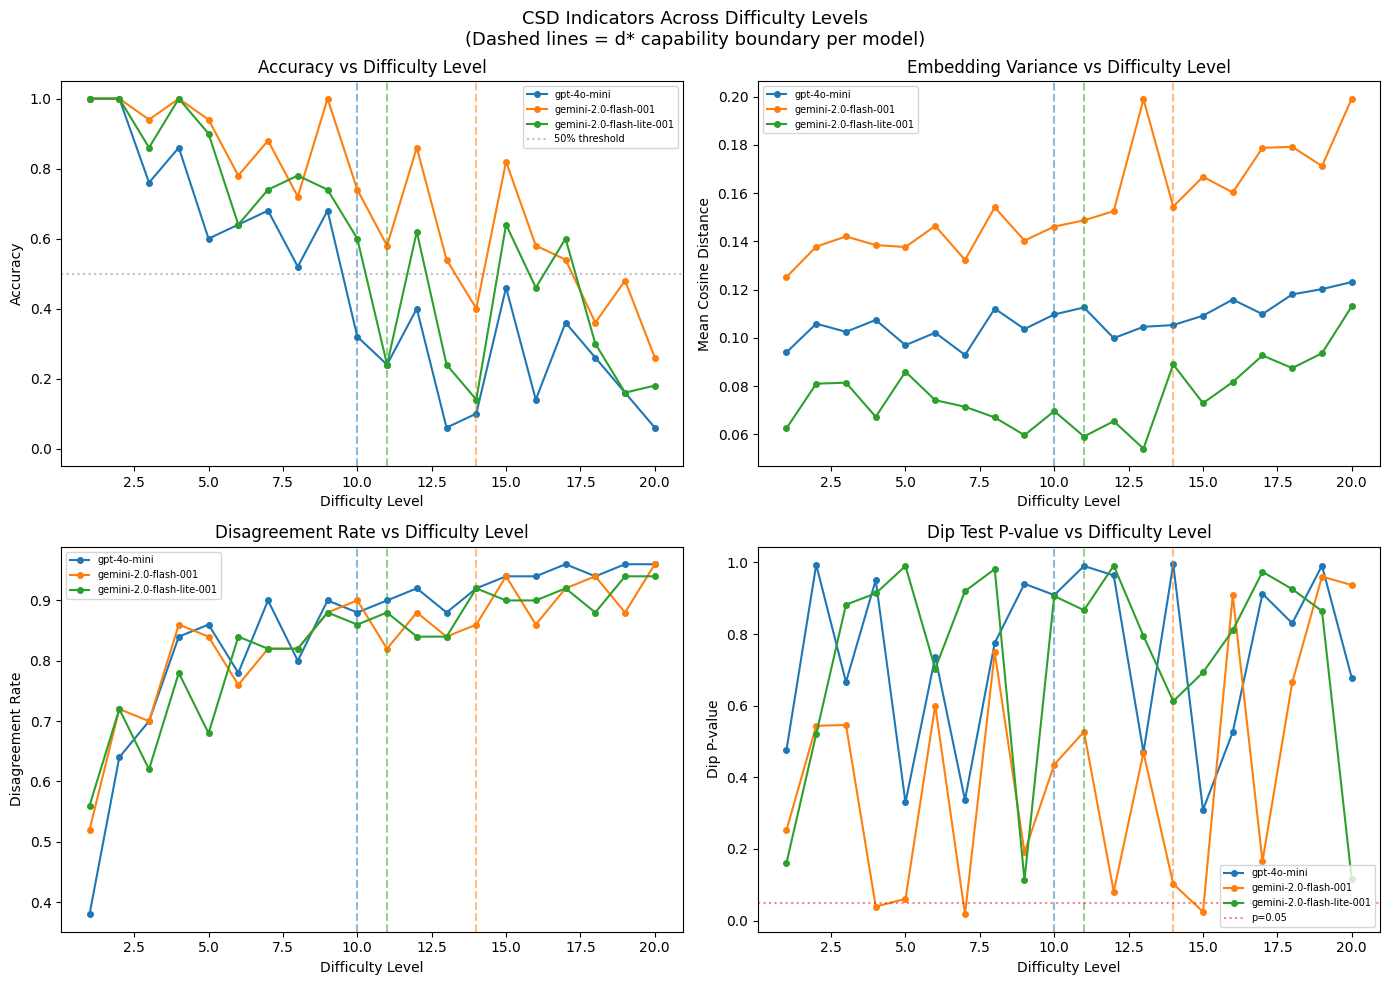

In [11]:
# --- Use pre-computed CSD indicators from original experiment metadata ---
# The demo data has 1 response per (model, level), so freshly-computed CSD indicators
# are trivial (N=1). Instead, use the pre-computed indicators stored in each example's
# metadata fields, which were computed from the full 50-response groups.

precomputed_indicators: dict[str, dict[int, dict]] = {}
for resp in all_responses:
    model = resp['metadata_model']
    level = resp['metadata_difficulty_level']
    precomputed_indicators.setdefault(model, {})[level] = {
        "accuracy": resp.get('metadata_csd_accuracy', 0.0),
        "embedding_variance": resp.get('metadata_csd_embedding_variance', 0.0),
        "pc1_variance": resp.get('metadata_csd_embedding_variance', 0.0),  # use emb_var as proxy
        "dip_statistic": resp.get('metadata_csd_dip_statistic', 0.0),
        "dip_pvalue": resp.get('metadata_csd_dip_pvalue', 1.0),
        "silhouette_score": resp.get('metadata_csd_silhouette_score', 0.0),
        "bimodality_coefficient": resp.get('metadata_csd_bimodality_coefficient', 0.0),
        "disagreement_rate": resp.get('metadata_csd_disagreement_rate', 1.0),
        "ashman_d": resp.get('metadata_csd_ashman_d', 0.0),
    }

# Re-run analysis using pre-computed indicators for meaningful results
precomp_analyses = []
for model in precomputed_indicators:
    analysis = analyze_model_results(model, precomputed_indicators[model])
    precomp_analyses.append(analysis)

# --- Summary Table ---
print("=" * 80)
print("MODEL ANALYSIS SUMMARY (from full experiment, 50 responses per group)")
print("=" * 80)
print(f"{'Model':<35} {'d*':>4} {'Scaling Exp':>12} {'R^2':>8} {'In Range':>9}")
print("-" * 80)
for a in precomp_analyses:
    short = a['model'].split('/')[-1]
    exp_str = f"{a['scaling_exponent']:.4f}" if a['scaling_exponent'] is not None else "N/A"
    r2_str = f"{a['scaling_r_squared']:.4f}" if a['scaling_r_squared'] is not None else "N/A"
    print(f"{short:<35} {a['d_star']:>4} {exp_str:>12} {r2_str:>8} {str(a['exponent_in_range']):>9}")

# Original experiment reference
orig_analysis = data.get('metadata', {}).get('analysis', {})
if orig_analysis.get('models'):
    print("\n--- Original Experiment Reference (3000 API calls) ---")
    for m in orig_analysis['models']:
        short = m['model'].split('/')[-1]
        print(f"  {short}: d*={m['d_star']}, scaling_exp={m.get('scaling_exponent')}")
    cc = orig_analysis.get('classifier_comparison', {})
    print(f"  Classifier: CSD F1={cc.get('csd_f1',0):.3f}, "
          f"Baseline F1={cc.get('baseline_disagreement_f1',0):.3f}")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_map = {'gpt-4o-mini': '#1f77b4', 'gemini-2.0-flash-001': '#ff7f0e', 'gemini-2.0-flash-lite-001': '#2ca02c'}

for a in precomp_analyses:
    short = a['model'].split('/')[-1]
    color = colors_map.get(short, 'gray')
    levels = sorted(a['per_level'].keys())
    accs = [a['per_level'][l]['accuracy'] for l in levels]
    vars_ = [a['per_level'][l]['embedding_variance'] for l in levels]
    disagr = [a['per_level'][l]['disagreement_rate'] for l in levels]
    dip_p = [a['per_level'][l]['dip_pvalue'] for l in levels]

    axes[0, 0].plot(levels, accs, 'o-', label=short, color=color, markersize=4)
    axes[0, 0].axvline(x=a['d_star'], linestyle='--', color=color, alpha=0.5)
    axes[0, 1].plot(levels, vars_, 'o-', label=short, color=color, markersize=4)
    axes[0, 1].axvline(x=a['d_star'], linestyle='--', color=color, alpha=0.5)
    axes[1, 0].plot(levels, disagr, 'o-', label=short, color=color, markersize=4)
    axes[1, 0].axvline(x=a['d_star'], linestyle='--', color=color, alpha=0.5)
    axes[1, 1].plot(levels, dip_p, 'o-', label=short, color=color, markersize=4)
    axes[1, 1].axvline(x=a['d_star'], linestyle='--', color=color, alpha=0.5)

axes[0, 0].set_title('Accuracy vs Difficulty Level')
axes[0, 0].set_xlabel('Difficulty Level')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].axhline(y=0.5, linestyle=':', color='gray', alpha=0.5, label='50% threshold')
axes[0, 0].legend(fontsize=7)
axes[0, 0].set_ylim(-0.05, 1.05)

axes[0, 1].set_title('Embedding Variance vs Difficulty Level')
axes[0, 1].set_xlabel('Difficulty Level')
axes[0, 1].set_ylabel('Mean Cosine Distance')
axes[0, 1].legend(fontsize=7)

axes[1, 0].set_title('Disagreement Rate vs Difficulty Level')
axes[1, 0].set_xlabel('Difficulty Level')
axes[1, 0].set_ylabel('Disagreement Rate')
axes[1, 0].legend(fontsize=7)

axes[1, 1].set_title('Dip Test P-value vs Difficulty Level')
axes[1, 1].set_xlabel('Difficulty Level')
axes[1, 1].set_ylabel('Dip P-value')
axes[1, 1].axhline(y=0.05, linestyle=':', color='red', alpha=0.5, label='p=0.05')
axes[1, 1].legend(fontsize=7)

plt.suptitle('CSD Indicators Across Difficulty Levels\n(Dashed lines = d* capability boundary per model)', fontsize=13)
plt.tight_layout()
plt.show()